In [19]:
import sys, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.optimizers import Adam

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

In [2]:
# --- GPU + Mixed Precision Setup (start cell) ---
from tensorflow.keras import mixed_precision

# Hide unnecessary info
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Check if GPU is loaded
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus[0].name}")
else:
    print("GPU NOT detected — TensorFlow will run on CPU")

mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision enabled (mixed_float16)")

print(f"TensorFlow version: {tf.__version__}")
print(f"Compute dtype: {mixed_precision.global_policy().compute_dtype}")
print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}")

GPU detected: /physical_device:GPU:0
Mixed precision enabled (mixed_float16)
TensorFlow version: 2.20.0
Compute dtype: float16
Variable dtype: float32


In [3]:
mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()
print(f"Data shape: {data.shape}")
print(f"Labels shape (before one-hot): {labels.shape}")

Loaded cached data from ../../data/processed/melspec_cache.npz
Data shape: (14975, 150, 150, 1)
Labels shape (before one-hot): (14975,)


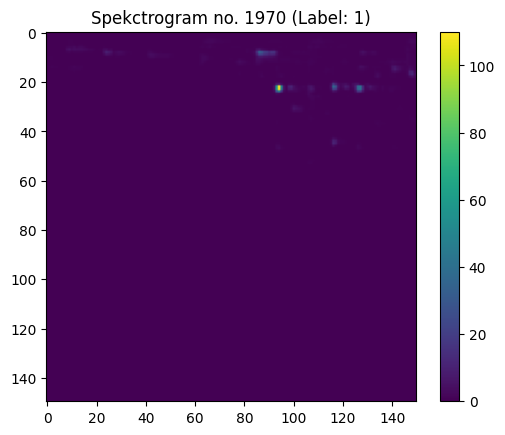

In [4]:
example_number = 1970
example_melspectogram_x = data[example_number]
example_melspectogram_y = labels[example_number]
plt.imshow(example_melspectogram_x.squeeze())
plt.title(f"Spekctrogram no. {example_number} (Label: {example_melspectogram_y})")
plt.colorbar()
plt.show()

In [5]:
labels = mgr.one_hot()
print(f"Labels shape (one-hot): {labels.shape}")

Labels shape (one-hot): (14975, 10)


In [6]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (11980, 150, 150, 1)
X_test shape: (2995, 150, 150, 1)
Y_train shape: (11980, 10)
Y_test shape: (2995, 10)


In [7]:
model = tf.keras.models.Sequential()

In [8]:
X_train[0].shape

(150, 150, 1)

In [9]:
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=X_train[0].shape))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Flatten())

model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=len(classes), activation='softmax'))

/mnt/c/Studia/Sem_5/Projektowe/GenreAI/.venv-wsl/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1768076394.298756   13370 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,712,330 (40.86 MB)

 Trainable params: 10,712,330 (40.86 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
training_history = model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

2026-01-10 21:20:01.774458: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 862560000 exceeds 10% of free system memory.
2026-01-10 21:20:08.725107: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 862560000 exceeds 10% of free system memory.


Epoch 1/30


2026-01-10 21:20:12.537747: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f88d000d3a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-10 21:20:12.537822: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-01-10 21:20:13.652132: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-10 21:20:15.762216: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-01-10 21:20:16.374903: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-10 21:20:18.

300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1717 - loss: 5.4324

2026-01-10 21:21:25.646066: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 215640000 exceeds 10% of free system memory.
2026-01-10 21:21:26.833626: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 215640000 exceeds 10% of free system memory.


300/300 ━━━━━━━━━━━━━━━━━━━━ 84s 101ms/step - accuracy: 0.2231 - loss: 3.3732 - val_accuracy: 0.3068 - val_loss: 1.8279
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.3563 - loss: 1.8069 - val_accuracy: 0.4725 - val_loss: 1.5664
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4773 - loss: 1.5144 - val_accuracy: 0.5563 - val_loss: 1.3294
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5752 - loss: 1.2507 - val_accuracy: 0.6198 - val_loss: 1.1802
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6579 - loss: 1.0322 - val_accuracy: 0.6557 - val_loss: 1.0380
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7112 - loss: 0.8605 - val_accuracy: 0.6603 - val_loss: 1.0523
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7650 - loss: 0.7178 - val_accuracy: 0.6811 - val_loss: 0.9586
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8010 - loss: 0.6134 - val_accuracy: 0.7

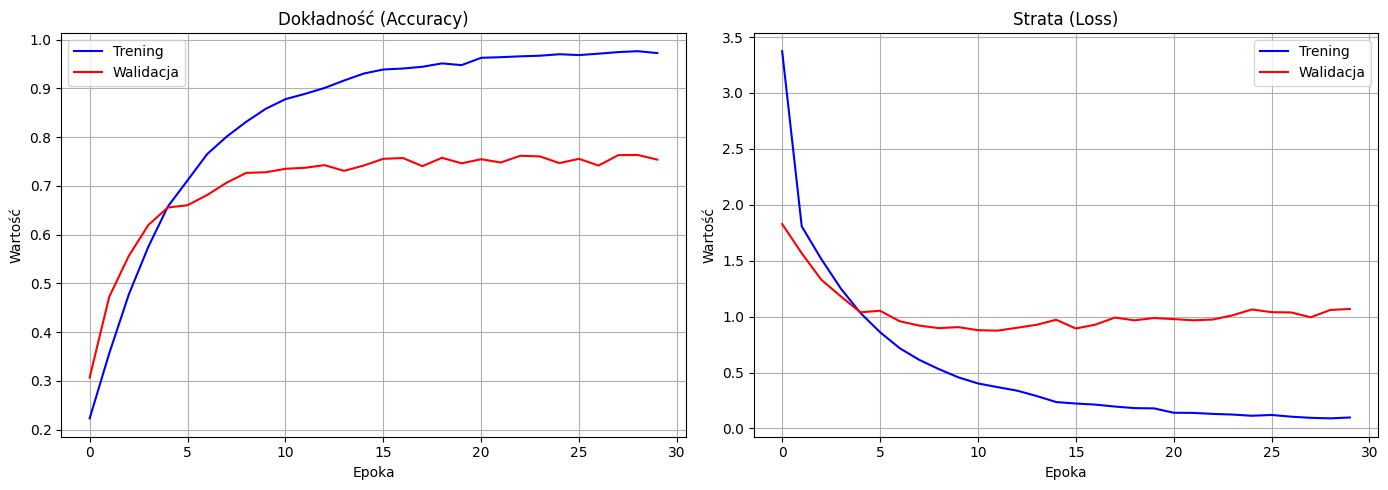

In [13]:
acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']
loss = training_history.history['loss']
val_loss = training_history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Trening', color='blue')
ax1.plot(val_acc, label='Walidacja', color='red')
ax1.set_title('Dokładność (Accuracy)')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Wartość')
ax1.legend()
ax1.grid(True)

ax2.plot(loss, label='Trening', color='blue')
ax2.plot(val_loss, label='Walidacja', color='red')
ax2.set_title('Strata (Loss)')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Wartość')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [17]:
# Ewaluacja na zbiorze testowym
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=1)
print(f"\nDokładność na zbiorze testowym: {test_acc:.2%}")
print(f"Strata na zbiorze testowym: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7526 - loss: 1.0590

Dokładność na zbiorze testowym: 75.26%
Strata na zbiorze testowym: 1.0590


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


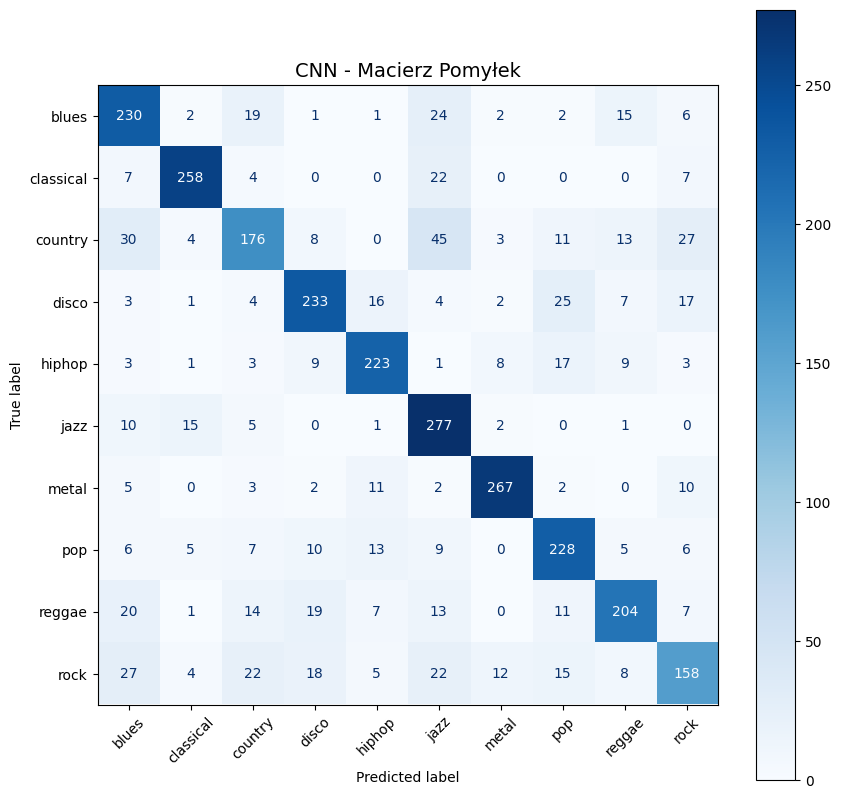


Raport klasyfikacji:
              precision    recall  f1-score   support

       blues       0.67      0.76      0.72       302
   classical       0.89      0.87      0.88       298
     country       0.68      0.56      0.61       317
       disco       0.78      0.75      0.76       312
      hiphop       0.81      0.81      0.81       277
        jazz       0.66      0.89      0.76       311
       metal       0.90      0.88      0.89       302
         pop       0.73      0.79      0.76       289
      reggae       0.78      0.69      0.73       296
        rock       0.66      0.54      0.59       291

    accuracy                           0.75      2995
   macro avg       0.76      0.75      0.75      2995
weighted avg       0.76      0.75      0.75      2995



In [20]:
Y_pred_proba = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)

cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('CNN - Macierz Pomyłek', fontsize=14)
plt.xticks(rotation=45)
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(Y_true_classes, Y_pred_classes, target_names=classes))

In [ ]:
model.save('../models/CNN_1.keras')
print("Model zapisany jako: ../models/CNN_1.keras")

Model zapisany jako: ../models/CNN_1.keras


: 